# SPX IV Surface Skew Dynamics: sticky strike vs sticky delta

This notebook takes the 523 reconstructed daily SPX IV surfaces (Jun 2021 - Jun 2023, built in ) and asks how the volatility smile *moves*.

**Roadmap**

0. **Look at the data** - raw option quotes, one day's smiles strike by strike (Natenberg Fig 24-3 / 24-5, on SPX)
1. **Smile features** - level / skew / curvature time series at each tenor
2. **One crash day under the microscope** - Natenberg's floating skew (Fig 24-4), tested on the biggest down-day in the sample
3. **The skew-stickiness ratio** - sticky delta vs sticky strike settled by regression, tenor by tenor
4. **PCA baseline** - the three classic linear factors
5. **ISOMAP vs PCA** - is there any nonlinear structure left in the skew dynamics?

Findings are summarized at the end.

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.seterr(divide='ignore', over='ignore', invalid='ignore')   # silence spurious Accelerate matmul warnings

IV = 'data/iv'
S = pd.read_parquet(f'{IV}/surfaces.parquet')                  # 523 days x 63 grid points
grid = json.load(open(f'{IV}/surface_grid.json'))
MATS, MONEY = grid['mats_days'], grid['moneyness']
cube = S.values.reshape(len(S), len(MATS), len(MONEY))         # (day, tenor, moneyness)
dates = S.index
print(f'surfaces: {S.shape[0]} days x {len(MATS)} tenors x {len(MONEY)} moneyness '
      f'({dates[0].date()} -> {dates[-1].date()})')
print('tenors (days):', MATS)
print('moneyness    :', MONEY)

surfaces: 523 days x 7 tenors x 9 moneyness (2021-06-01 -> 2023-06-30)
tenors (days): [30, 60, 91, 122, 182, 273, 365]
moneyness    : [0.85, 0.9, 0.95, 0.975, 1.0, 1.025, 1.05, 1.1, 1.15]


## 0. First, look at the data

Two layers sit in `data/iv/`:

- **Raw quotes** — one parquet per trading day (523 files, `iv_2021-06-01.parquet` ... `iv_2023-06-30.parquet`). Each row is one option: `expiry, T, strike, F, r, moneyness, is_call, mid, iv`. The forward `F` and rate `r` come from put-call parity; `iv` is the Black-76 inversion of the mid price. Roughly 5,000-6,000 options across ~15 expiries per day.
- **The surface panel** — `surfaces.parquet`, each day collapsed onto the fixed 7 tenors x 9 moneyness grid. All the dynamics analysis below runs on this.

Below: actual rows from day one, and that day's smiles plotted strike by strike. This is exactly Natenberg's Figure 24-3 / 24-5 (FTSE 100, March 2012), reproduced on SPX: implied vol falls as the exercise price rises, and the short-dated smile is the steepest.

iv_2021-06-01.parquet: 5790 options, 15 expiries, F(nearest) = 4198
      expiry         T  strike            F         r  moneyness  is_call      mid        iv
0 2021-06-18  0.046543  4310.0  4198.364063  0.006418   1.026590     True    6.350  0.107470
1 2021-06-18  0.046543  4125.0  4198.364063  0.006418   0.982526     True  100.350  0.157056
2 2021-06-18  0.046543  4175.0  4198.364063  0.006418   0.994435     True   62.450  0.138539
3 2021-06-18  0.046543  4175.0  4198.364063  0.006418   0.994435    False   39.050  0.138418
4 2021-06-18  0.046543  4275.0  4198.364063  0.006418   1.018254     True   13.450  0.111985
5 2021-06-18  0.046543  4310.0  4198.364063  0.006418   1.026590    False  117.850  0.106937
6 2021-06-18  0.046543  4400.0  4198.364063  0.006418   1.048027     True    1.075  0.112793
7 2021-06-18  0.046543  4400.0  4198.364063  0.006418   1.048027    False  202.850  0.116070


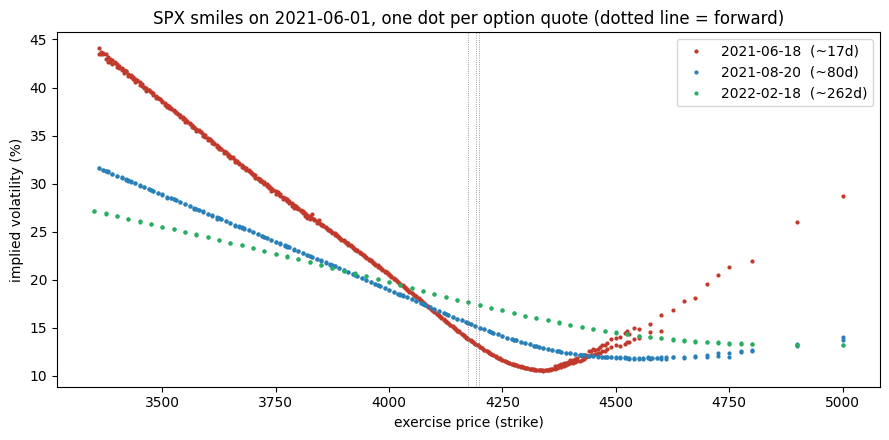

In [2]:
day0 = pd.read_parquet(f'{IV}/iv_2021-06-01.parquet')
print(f'iv_2021-06-01.parquet: {len(day0)} options, {day0["expiry"].nunique()} expiries, '
      f'F(nearest) = {day0["F"].iloc[0]:.0f}')
print(day0.head(8).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
targets = [30, 91, 273]
colors = ['#C0392B', '#2980B9', '#27AE60']
for tgt, c in zip(targets, colors):
    exp = day0.loc[(day0['T'] * 365.25 - tgt).abs().idxmin(), 'expiry']
    e = day0[(day0['expiry'] == exp) & day0['moneyness'].between(0.8, 1.2)].sort_values('strike')
    ax.plot(e['strike'], e['iv'] * 100, '.', ms=4, color=c,
            label=f'{exp.date()}  (~{e["T"].iloc[0]*365.25:.0f}d)')
    ax.axvline(e['F'].iloc[0], color='gray', lw=0.6, ls=':')
ax.set_xlabel('exercise price (strike)'); ax.set_ylabel('implied volatility (%)')
ax.set_title('SPX smiles on 2021-06-01, one dot per option quote (dotted line = forward)')
ax.legend()
plt.tight_layout(); plt.show()

### Same smiles in standard-deviation units (Natenberg p. 493)

The fan of smiles above is hard to compare across expirations: is a 0.95 strike "far" from the money? It depends on the tenor — a 5% drop is a ~2-sigma event for a 30d option but well under 1 sigma for a 1-year option. Natenberg's fix is to relabel each strike by *how many standard deviations it sits from the money*:

$$z = \frac{\ln(K/F)}{\sigma\sqrt{T}}$$

(using the forward $F$, per his own footnote, and the expiry's ATM vol for $\sigma$; ATM is exactly $z=0$.)

If downside fear "per unit of rarity" were identical across tenors, all the smiles would collapse onto a single curve in $z$. Natenberg's verdict on his FTSE figure: *"the skews appear to be similar, but they are clearly not identical"* — let's see what SPX says, including how the near-ATM slope per sigma actually compares across tenors.

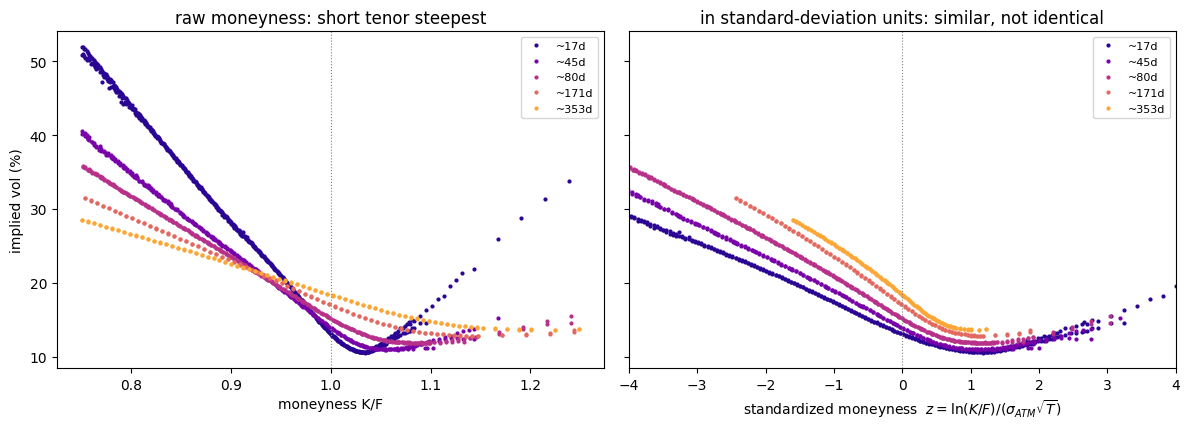

near-ATM skew slope (|z| <= 1), 2021-06-01:
       slope per ln K  slope per sigma (z)
tenor                                     
~17d           -1.239               -0.035
~45d           -0.872               -0.043
~80d           -0.676               -0.048
~171d          -0.498               -0.058
~353d          -0.365               -0.066


In [3]:
targets2 = [30, 60, 91, 182, 365]
cmap2 = plt.cm.plasma(np.linspace(0.05, 0.8, len(targets2)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
rows = []
for tgt, c in zip(targets2, cmap2):
    exp = day0.loc[(day0['T'] * 365.25 - tgt).abs().idxmin(), 'expiry']
    e = day0[(day0['expiry'] == exp) & day0['moneyness'].between(0.75, 1.25)].sort_values('strike')
    T_, F_ = e['T'].iloc[0], e['F'].iloc[0]
    atm = np.interp(F_, e['strike'], e['iv'])
    z = np.log(e['strike'] / F_).values / (atm * np.sqrt(T_))
    lab = f'~{T_*365.25:.0f}d'
    ax[0].plot(e['moneyness'], e['iv'] * 100, '.', ms=4, color=c, label=lab)
    ax[1].plot(z, e['iv'] * 100, '.', ms=4, color=c, label=lab)
    near = np.abs(z) <= 1
    rows.append({'tenor': lab,
                 'slope per ln K': np.polyfit(np.log(e['strike'][near] / F_), e['iv'][near], 1)[0],
                 'slope per sigma (z)': np.polyfit(z[near], e['iv'][near], 1)[0]})
ax[0].axvline(1.0, color='gray', lw=0.8, ls=':')
ax[0].set_xlabel('moneyness K/F'); ax[0].set_ylabel('implied vol (%)')
ax[0].set_title('raw moneyness: short tenor steepest')
ax[1].axvline(0, color='gray', lw=0.8, ls=':')
ax[1].set_xlim(-4, 4)
ax[1].set_xlabel(r'standardized moneyness  $z=\ln(K/F)/(\sigma_{ATM}\sqrt{T})$')
ax[1].set_title('in standard-deviation units: similar, not identical')
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('near-ATM skew slope (|z| <= 1), 2021-06-01:')
print(pd.DataFrame(rows).set_index('tenor').round(3))

**Reading the table.** In raw log-strike units the ~17d skew (-1.24) is **3.4× steeper** than the ~1y skew (-0.37) — the fan in the left panel. Dividing by $\sigma\sqrt{T}$ doesn't just flatten that difference, it **over-corrects**: per standard deviation, the *long*-dated skew (-0.066) is now ~1.9× steeper than the short-dated one (-0.035). The true tenor-scaling of the skew sits *between* the two coordinate systems — the classic empirical "$\sim 1/\sqrt{T}$ skew law". So Natenberg's *"similar, but clearly not identical"* is exactly right: $z$-units make smiles comparable across expirations, but the residual tenor pattern is real information, the same skew-term-structure economics that section 1 measures with the 0.95/1.05 pillars.

In [4]:
# sanity checks: is the panel healthy, and does it agree with the raw quotes?
print(f'panel: {S.shape[0]} days x {S.shape[1]} grid points   '
      f'NaNs: {S.isna().sum().sum()}   IV range: {S.values.min():.3f} - {S.values.max():.3f}')
skew30_all = cube[:, 0, MONEY.index(0.95)] - cube[:, 0, MONEY.index(1.05)]
print(f'days with positive 30d skew (puts over calls): {(skew30_all > 0).mean():.1%}')
print(f'days where 365d ATM > 30d ATM (upward term structure): '
      f'{(cube[:, -1, MONEY.index(1.0)] > cube[:, 0, MONEY.index(1.0)]).mean():.1%}')

# cross-check: grid value at (30d, ATM) vs the nearest raw quote, sampled monthly
checks = []
for f in sorted(glob.glob(f'{IV}/iv_*.parquet'))[::21]:
    d = pd.read_parquet(f)
    dt = pd.Timestamp(os.path.basename(f)[3:13])
    exp = d.loc[(d['T'] * 365.25 - 30).abs().idxmin(), 'expiry']
    e = d[d['expiry'] == exp]
    raw_atm = e.loc[(e['moneyness'] - 1.0).abs().idxmin(), 'iv']
    grid_atm = cube[dates.get_loc(dt), 0, MONEY.index(1.0)]
    checks.append(abs(raw_atm - grid_atm))
print(f'\ngrid ATM-30d vs nearest raw quote, {len(checks)} sampled days: '
      f'median gap {np.median(checks)*100:.2f} vol pts, max {np.max(checks)*100:.2f}')
print('(small gaps expected: the grid interpolates across expiries in total variance,')
print(' the raw quote sits at one expiry near 30d, not exactly 30d)')

panel: 523 days x 63 grid points   NaNs: 0   IV range: 0.090 - 0.433
days with positive 30d skew (puts over calls): 100.0%
days where 365d ATM > 30d ATM (upward term structure): 74.0%

grid ATM-30d vs nearest raw quote, 25 sampled days: median gap 0.61 vol pts, max 2.11
(small gaps expected: the grid interpolates across expiries in total variance,
 the raw quote sits at one expiry near 30d, not exactly 30d)


## 1. Smile features: turning the surface into skew time series

At each tenor the smile is 9 IV points across moneyness. Three numbers summarize its shape:

- **level** = `IV(1.00)` — ATM vol, how expensive options are overall
- **skew** = `IV(0.95) - IV(1.05)` — how much more expensive downside protection is than upside (positive for SPX)
- **curvature** = `IV(0.95) + IV(1.05) - 2·IV(1.00)` — how bent the smile is (fat-tail premium)

We also keep the **signed slope** `∂IV/∂ln K ≈ (IV(1.05) - IV(0.95)) / ln(1.05/0.95)` (negative for SPX) — that exact quantity is what the skew-stickiness ratio in section 2 needs.

sample means of smile features by tenor:
          level    skew   slope    curv
tenor_d                                
30       0.1880  0.0761 -0.7604  0.0142
60       0.1914  0.0674 -0.6731  0.0069
91       0.1953  0.0607 -0.6065  0.0041
122      0.1989  0.0555 -0.5547  0.0024
182      0.2037  0.0483 -0.4821  0.0010
273      0.2073  0.0417 -0.4170  0.0003
365      0.2092  0.0367 -0.3670 -0.0000


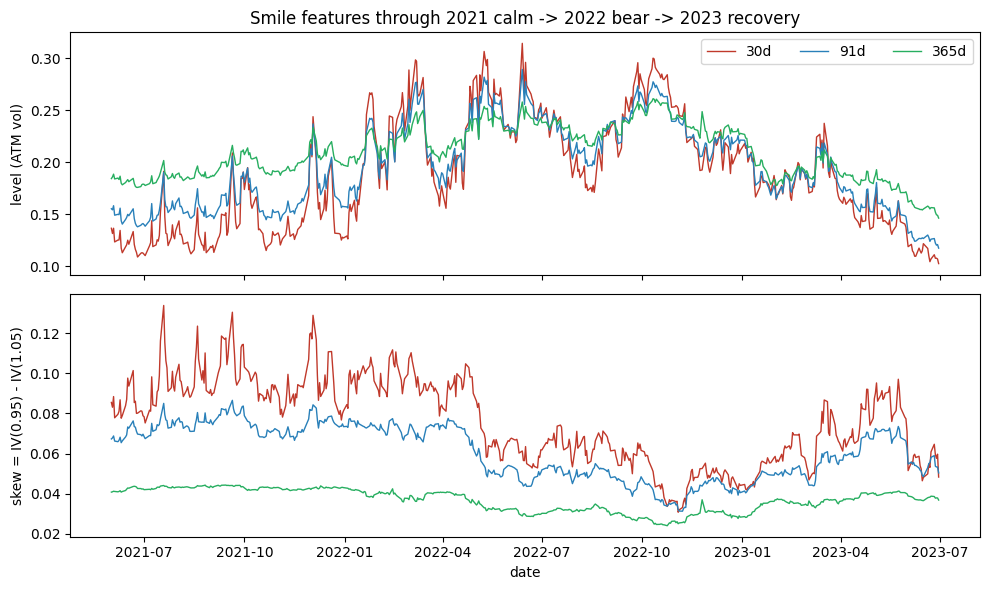

In [5]:
mi = {m: j for j, m in enumerate(MONEY)}
DLNK = np.log(1.05 / 0.95)                       # log-moneyness gap between the two skew pillars

cols = {}
for i, Td in enumerate(MATS):
    iv95, atmv, iv105 = cube[:, i, mi[0.95]], cube[:, i, mi[1.0]], cube[:, i, mi[1.05]]
    cols[(Td, 'level')] = atmv
    cols[(Td, 'skew')]  = iv95 - iv105
    cols[(Td, 'slope')] = (iv105 - iv95) / DLNK
    cols[(Td, 'curv')]  = iv95 + iv105 - 2 * atmv
feat = pd.DataFrame(cols, index=dates)

summ = pd.DataFrame({stat: [feat[(Td, stat)].mean() for Td in MATS]
                     for stat in ['level', 'skew', 'slope', 'curv']}, index=MATS)
summ.index.name = 'tenor_d'
print('sample means of smile features by tenor:')
print(summ.round(4))

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for Td, c in [(30, '#C0392B'), (91, '#2980B9'), (365, '#27AE60')]:
    ax[0].plot(dates, feat[(Td, 'level')], lw=1, color=c, label=f'{Td}d')
    ax[1].plot(dates, feat[(Td, 'skew')], lw=1, color=c, label=f'{Td}d')
ax[0].set_ylabel('level (ATM vol)'); ax[0].legend(ncol=3)
ax[0].set_title('Smile features through 2021 calm -> 2022 bear -> 2023 recovery')
ax[1].set_ylabel('skew = IV(0.95) - IV(1.05)'); ax[1].set_xlabel('date')
plt.tight_layout(); plt.show()

## 2. One crash day under the microscope: the textbook's floating skew, on real data

Natenberg (ch. 24) rejects a *fixed* sticky-strike skew and proposes the **floating skew**: when the underlying moves, slide the whole curve horizontally with it (his Figure 24-4a), and shift it vertically when vol changes (24-4b). His figures are sketches; here is the real thing.

We take the **largest one-day forward drop in the sample**, plot the same expiry's quotes the day before and the day of, in both coordinate systems:

- **Against strike**: did each exercise price keep its vol (sticky strike)?
- **Against moneyness K/F**: did the *shape* stay put and just float with the forward (sticky delta)?

And the one number to watch: what happened to **ATM vol**? Sticky delta says *unchanged*. Sticky strike says *up by (slope x return)*, because the ATM label slid down the curve. The table printed below compares both predictions with what actually happened.

### The 25-delta skew: Natenberg's canonical measure

The grid-based skew (`IV(0.95) - IV(1.05)`) is convenient, but the industry-standard skew measure is the **25-delta risk reversal**: the implied vol of a -25 delta put minus the implied vol of a +25 delta call. This is the strike pair where skewness sensitivity is typically maximal (Natenberg p. 258).

To compute it from our raw files, we invert Black-76 for delta: for each option, compute $d_1$ and find the strikes where delta ≈ ±0.25. The resulting time series should track the grid-based skew closely — if it doesn't, the grid interpolation is the problem, not the market.

We sample ~50 days evenly to keep runtime reasonable; the correlation across the full panel would be even tighter.

25-delta risk reversal sampled on 53 days (nearest 30d expiry):
             put25  call25    rr25       T  grid_skew
date                                                 
2021-06-01  0.1657  0.1127  0.0530  0.0465     0.0855
2021-06-15  0.1589  0.1010  0.0579  0.0849     0.0870
2021-06-30  0.1240  0.0804  0.0436  0.0438     0.0789
2021-07-15  0.1733  0.1049  0.0684  0.0986     0.0989
2021-07-29  0.1544  0.0977  0.0567  0.0602     0.0912
2021-08-12  0.1585  0.0966  0.0619  0.0986     0.0881
2021-08-26  0.1720  0.0983  0.0737  0.0602     0.1102
2021-09-10  0.2036  0.1171  0.0865  0.0958     0.1187

correlation(25d RR, grid 0.95/1.05 skew) = 0.778


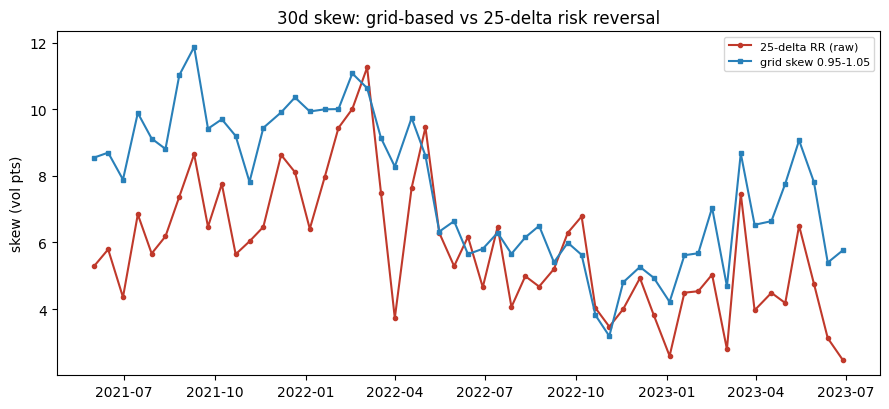

In [6]:
from scipy.stats import norm

def _black76_delta_vec(F, K, T, sigma, r, is_call):
    """Vectorized Black-76 delta for a full expiry's options."""
    sq = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / sq
    disc = np.exp(-r * T)
    return np.where(is_call, disc * norm.cdf(d1), disc * (norm.cdf(d1) - 1.0))

sample_days = sorted(glob.glob(f'{IV}/iv_*.parquet'))[::10]   # ~52 days
rr25 = []
for f in sample_days:
    dt = pd.Timestamp(os.path.basename(f)[3:13])
    d = pd.read_parquet(f)
    # target expiry nearest 30d
    exp = d.loc[(d['T'] * 365.25 - 30).abs().idxmin(), 'expiry']
    e = d[d['expiry'] == exp].copy()
    e['delta'] = _black76_delta_vec(e['F'].values, e['strike'].values,
                                     e['T'].values, e['iv'].values,
                                     e['r'].values, e['is_call'].values)
    puts = e[~e['is_call']].sort_values('delta')
    calls = e[e['is_call']].sort_values('delta')
    # interpolate IV at +/-0.25 delta
    put25 = np.interp(-0.25, puts['delta'].values, puts['iv'].values)
    call25 = np.interp(+0.25, calls['delta'].values, calls['iv'].values)
    rr25.append({'date': dt, 'put25': put25, 'call25': call25,
                 'rr25': put25 - call25, 'T': e['T'].iloc[0]})
rr = pd.DataFrame(rr25).set_index('date').sort_index()

# align with the grid-based 30d skew on the same sampled dates
grid_skew = feat[(30, 'skew')].reindex(rr.index)
rr['grid_skew'] = grid_skew.values

print(f'25-delta risk reversal sampled on {len(rr)} days (nearest 30d expiry):')
print(rr.head(8).round(4))
print(f'\ncorrelation(25d RR, grid 0.95/1.05 skew) = {rr["rr25"].corr(rr["grid_skew"]):.3f}')

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(rr.index, rr['rr25'] * 100, 'o-', ms=3, color='#C0392B', label='25-delta RR (raw)')
ax.plot(rr.index, rr['grid_skew'] * 100, 's-', ms=3, color='#2980B9', label='grid skew 0.95-1.05')
ax.set_ylabel('skew (vol pts)')
ax.set_title('30d skew: grid-based vs 25-delta risk reversal')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

biggest drop: 2022-06-10 -> 2022-06-13   forward return -4.70%


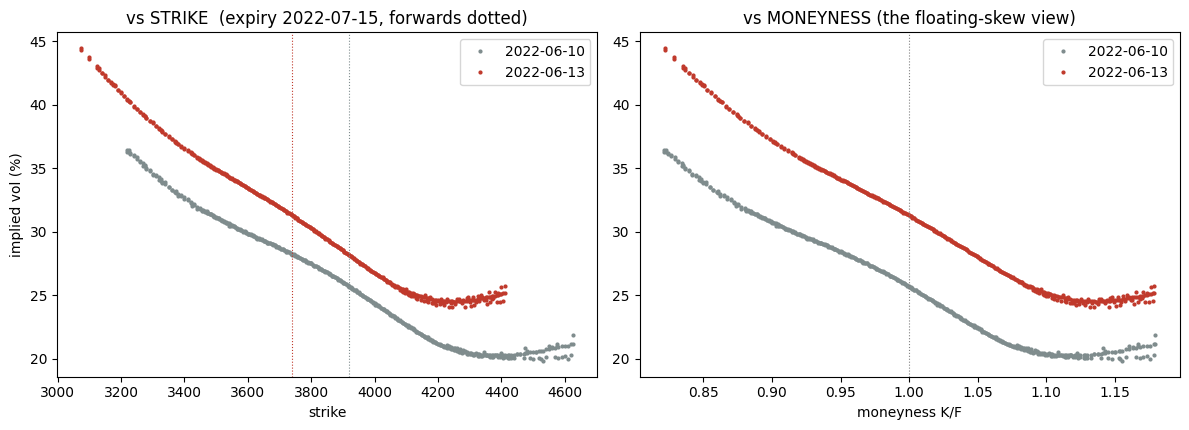

30d ATM vol on 2022-06-10: 25.8%
prediction for 2022-06-13 after a -4.70% move:
  sticky delta  : 25.8%   (no change: smile floats with F)
  sticky strike : 28.6%   (slide along the fixed curve: slope x return)
  actual        : 31.4%


In [7]:
# constant-maturity 30d forward (one scan of the raw files; reused by the SSR section below)
t30 = 30 / 365.25
rows = []
for f in sorted(glob.glob(f'{IV}/iv_*.parquet')):
    d = pd.read_parquet(f, columns=['T', 'F']).drop_duplicates('T').sort_values('T')
    rows.append({'date': pd.Timestamp(os.path.basename(f)[3:13]),
                 'lnF30': np.interp(t30, d['T'].values, np.log(d['F'].values))})
lnF30 = pd.DataFrame(rows).set_index('date')['lnF30'].reindex(dates)
dlnF = lnF30.diff()

i = int(np.nanargmin(dlnF.values))                       # biggest one-day forward drop
d0, d1, ret = dates[i - 1], dates[i], dlnF.iloc[i]
print(f'biggest drop: {d0.date()} -> {d1.date()}   forward return {ret:+.2%}')

q0 = pd.read_parquet(f"{IV}/iv_{d0.date()}.parquet")
q1 = pd.read_parquet(f"{IV}/iv_{d1.date()}.parquet")
common = set(q0['expiry']) & set(q1['expiry'])
q0c = q0[q0['expiry'].isin(common)]
exp = q0c.loc[(q0c['T'] * 365.25 - 30).abs().idxmin(), 'expiry']
e0 = q0[(q0['expiry'] == exp) & q0['moneyness'].between(0.82, 1.18)].sort_values('strike')
e1 = q1[(q1['expiry'] == exp) & q1['moneyness'].between(0.82, 1.18)].sort_values('strike')
F0, F1 = e0['F'].iloc[0], e1['F'].iloc[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for e, c, lab in [(e0, '#7F8C8D', f'{d0.date()}'), (e1, '#C0392B', f'{d1.date()}')]:
    ax[0].plot(e['strike'], e['iv'] * 100, '.', ms=4, color=c, label=lab)
    ax[1].plot(e['moneyness'], e['iv'] * 100, '.', ms=4, color=c, label=lab)
ax[0].axvline(F0, color='#7F8C8D', lw=0.8, ls=':'); ax[0].axvline(F1, color='#C0392B', lw=0.8, ls=':')
ax[0].set_xlabel('strike'); ax[0].set_ylabel('implied vol (%)')
ax[0].set_title(f'vs STRIKE  (expiry {exp.date()}, forwards dotted)')
ax[1].axvline(1.0, color='gray', lw=0.8, ls=':')
ax[1].set_xlabel('moneyness K/F'); ax[1].set_title('vs MONEYNESS (the floating-skew view)')
ax[0].legend(); ax[1].legend()
plt.tight_layout(); plt.show()

atm0, atm1 = feat[(30, 'level')].iloc[i - 1], feat[(30, 'level')].iloc[i]
slope0 = feat[(30, 'slope')].iloc[i - 1]
print(f'30d ATM vol on {d0.date()}: {atm0:.1%}')
print(f'prediction for {d1.date()} after a {ret:+.2%} move:')
print(f'  sticky delta  : {atm0:.1%}   (no change: smile floats with F)')
print(f'  sticky strike : {atm0 + slope0 * ret:.1%}   (slide along the fixed curve: slope x return)')
print(f'  actual        : {atm1:.1%}')

## 3. Sticky strike vs sticky delta: the skew-stickiness ratio (SSR)

The crash day was one observation. Now run the same comparison over all 522 daily changes — that is the **skew-stickiness ratio**:

$$\text{SSR} = \frac{\beta\ \text{from regressing}\ \Delta\sigma_{ATM}\ \text{on}\ \Delta\ln F}{\text{average skew slope}\ \partial\sigma/\partial\ln K}
\qquad 0 = \text{sticky delta},\quad 1 = \text{sticky strike},\quad \approx 2 = \text{stoch-vol limit}$$

- **Sticky delta** predicts $\beta = 0$: the smile floats with moneyness, so ATM vol ignores spot moves.
- **Sticky strike** predicts $\beta = $ skew slope: ATM vol changes exactly by sliding along a fixed curve, so SSR = 1.
- **Stochastic-vol models** predict SSR between 1 and 2 at short tenor: the slide *plus* a genuine vol jump correlated with the spot move.

For the forward return we use the constant-maturity 30d forward built above (day-over-day carry change is negligible next to ~1% daily moves).

          beta  reg_R2  avg_slope    SSR
tenor_d                                 
30      -0.992   0.658     -0.760  1.305
60      -0.797   0.707     -0.673  1.184
91      -0.684   0.728     -0.606  1.128
122     -0.606   0.740     -0.555  1.092
182     -0.506   0.758     -0.482  1.049
273     -0.420   0.774     -0.417  1.006
365     -0.352   0.700     -0.367  0.959


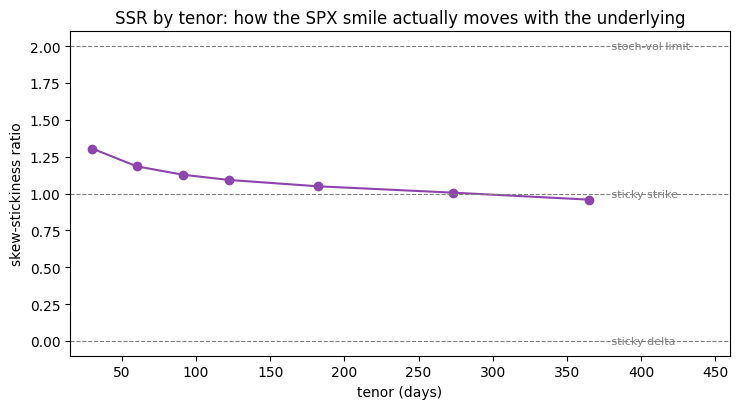

In [8]:
res = []
for Td in MATS:
    datm = feat[(Td, 'level')].diff()
    ok = datm.notna() & dlnF.notna()
    x, y = dlnF[ok].values, datm[ok].values
    beta = np.polyfit(x, y, 1)[0]                    # d(ATM vol) / d(ln F)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    slope_bar = feat[(Td, 'slope')].mean()           # average d(IV)/d(ln K), negative for SPX
    res.append({'tenor_d': Td, 'beta': beta, 'reg_R2': r2,
                'avg_slope': slope_bar, 'SSR': beta / slope_bar})
ssr = pd.DataFrame(res).set_index('tenor_d')
print(ssr.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(ssr.index, ssr['SSR'], 'o-', color='#8E44AD', lw=1.5)
for v, lab in [(0, 'sticky delta'), (1, 'sticky strike'), (2, 'stoch-vol limit')]:
    ax.axhline(v, ls='--', lw=0.8, color='gray')
    ax.text(378, v, f' {lab}', va='center', fontsize=8, color='gray')
ax.set_xlim(15, 460)
ax.set_xlabel('tenor (days)'); ax.set_ylabel('skew-stickiness ratio')
ax.set_title('SSR by tenor: how the SPX smile actually moves with the underlying')
plt.tight_layout(); plt.show()

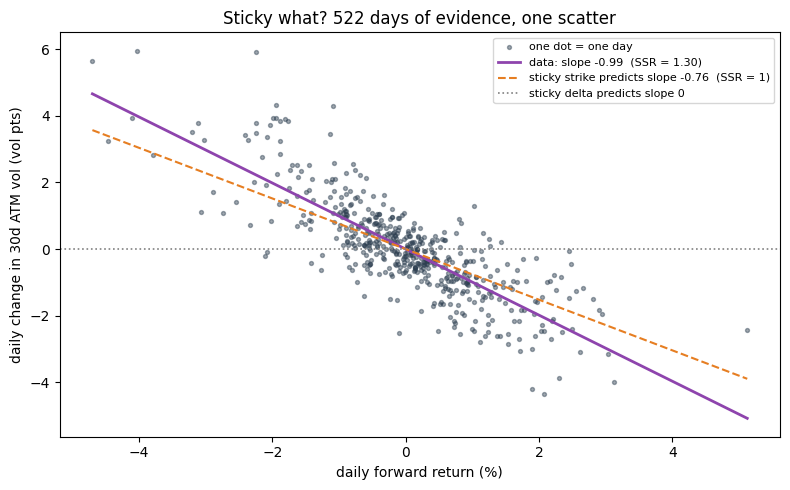

In [9]:
# the regression behind SSR(30d), shown point by point: 522 daily changes
datm30 = feat[(30, 'level')].diff()
ok = datm30.notna() & dlnF.notna()
x, y = dlnF[ok].values, datm30[ok].values * 100
beta30 = ssr.loc[30, 'beta']
slope30 = ssr.loc[30, 'avg_slope']

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x * 100, y, s=8, color='#2C3E50', alpha=0.45, label='one dot = one day')
xx = np.linspace(x.min(), x.max(), 2)
ax.plot(xx * 100, beta30 * xx * 100, color='#8E44AD', lw=2,
        label=f'data: slope {beta30:.2f}  (SSR = {beta30/slope30:.2f})')
ax.plot(xx * 100, slope30 * xx * 100, '--', color='#E67E22', lw=1.5,
        label=f'sticky strike predicts slope {slope30:.2f}  (SSR = 1)')
ax.axhline(0, color='gray', lw=1.2, ls=':', label='sticky delta predicts slope 0')
ax.set_xlabel('daily forward return (%)')
ax.set_ylabel('daily change in 30d ATM vol (vol pts)')
ax.set_title('Sticky what? 522 days of evidence, one scatter')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Reconciling the textbook with the SSR

Natenberg's floating skew and our SSR sound contradictory ("the book says the smile floats with moneyness, the regression says sticky strike wins") — they are not. They answer different questions, because the smile has two dials: **shape** and **height**.

| question | sticky delta (floating skew) says | sticky strike says | the data says |
|---|---|---|---|
| What happens to the smile's *shape* in moneyness coordinates? | unchanged | distorts as F moves | **~unchanged** (one level factor = 93% of variance) |
| What happens to *ATM vol* when F moves? | nothing (SSR = 0) | slope x return (SSR = 1) | **1.3 x slope x return at 30d** (SSR = 1.31) |

- The crash-day picture above shows both at once: in moneyness coordinates the curve keeps its shape — but it does **not** stay put, it jumps *up*. The vertical jump is exactly what sticky delta ignores, and it is strongly correlated with the spot move (the leverage effect).
- So: **moneyness is the right coordinate system for storing the smile** (Natenberg's real point — and why our 7x9 grid is built on K/F), while **sticky strike is the better approximation for predicting ATM vol**, because "float left + jump up" happens to land close to "strikes kept their vols".
- The SSR by tenor quantifies the leftover: 1.31 at 30d (vol jumps *more* than the slide explains — stochastic-vol territory), ~0.96 at 1y (almost exactly sticky strike).

## 4. PCA baseline: the three classic linear factors

Cont & da Fonseca (2002) showed IV surface variation is dominated by ~3 **linear** factors: a parallel **level** shift, a **term-structure** tilt, and a **moneyness skew** tilt. If that holds here, the first 3 PCs should explain ~99% of variance and their loadings (shown as 7×9 heatmaps) should look like exactly those three patterns. This is the benchmark any nonlinear method has to beat.

explained variance: PC1 93.3%   PC2 4.1%   PC3 1.6%   (first 3 cumulative: 99.0%)


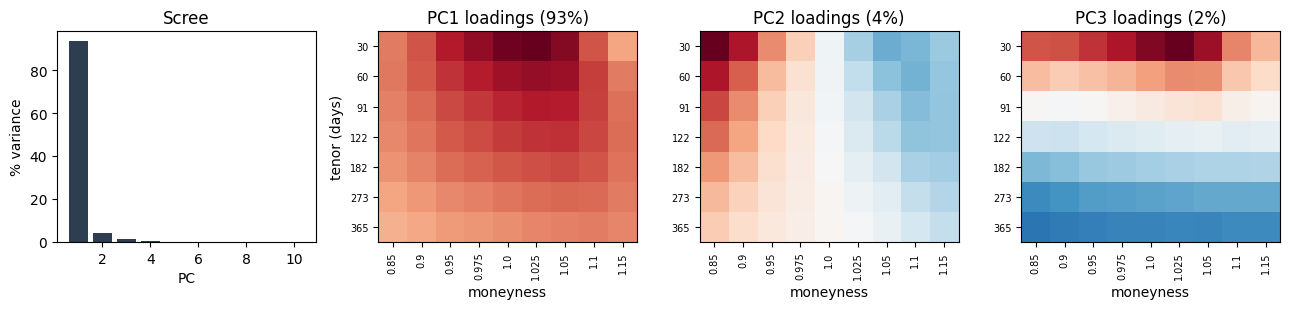

In [10]:
from sklearn.decomposition import PCA

X = S.values - S.values.mean(axis=0)             # demeaned, kept in vol units
pca = PCA(n_components=10).fit(X)
evr = pca.explained_variance_ratio_
print(f'explained variance: PC1 {evr[0]:.1%}   PC2 {evr[1]:.1%}   PC3 {evr[2]:.1%}'
      f'   (first 3 cumulative: {evr[:3].sum():.1%})')

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
axes[0].bar(range(1, 11), evr * 100, color='#2C3E50')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('% variance'); axes[0].set_title('Scree')
for k in range(3):
    L = pca.components_[k].reshape(len(MATS), len(MONEY))
    axes[k + 1].imshow(L, aspect='auto', cmap='RdBu_r', vmin=-np.abs(L).max(), vmax=np.abs(L).max())
    axes[k + 1].set_title(f'PC{k + 1} loadings ({evr[k]:.0%})')
    axes[k + 1].set_xticks(range(len(MONEY))); axes[k + 1].set_xticklabels(MONEY, rotation=90, fontsize=7)
    axes[k + 1].set_yticks(range(len(MATS))); axes[k + 1].set_yticklabels(MATS, fontsize=7)
    axes[k + 1].set_xlabel('moneyness')
axes[1].set_ylabel('tenor (days)')
plt.tight_layout(); plt.show()

## 5. ISOMAP vs PCA: is there nonlinear structure in the skew dynamics?

Earlier notebooks (`DS4FE_IV_Surface_DimReduction`, `DS4FE_IV_Surface_Representation_Test`) found no nonlinear edge in overall variance terms. Here we target the two places nonlinearity is *supposed* to live:

- **Level–skew coupling**: empirically, when vol rises the smile reshapes — level and skew co-move along a *curved* path, which PCA must spend 2–3 linear axes to describe but a manifold method could parameterize with fewer coordinates.
- **Regime hysteresis**: vol spikes fast and decays slow, so stress-on and stress-off may trace *different* paths — a loop in state space, visible in an embedding colored by time.

Three checks: (1) **linear-decode R²** — reconstruct all 63 grid IVs from k embedding coordinates, ISOMAP vs PCA at the same k; (2) **interpretability** — correlate ISOMAP coordinates with level / term-slope / skew to see if it found anything besides the linear factors; (3) **the pictures** — PC1–PC2, ISOMAP 1–2, and the raw level-vs-skew plane, all colored by time, to look for the coupling curve and hysteresis loop directly.

linear-decode R^2 (reconstruct all 63 grid IVs from k coordinates):
  k=1:   ISOMAP 0.928   PCA 0.933
  k=2:   ISOMAP 0.967   PCA 0.975
  k=3:   ISOMAP 0.978   PCA 0.990

correlation of ISOMAP coordinates with the interpretable drivers:
                       ISO1  ISO2  ISO3
level (91d ATM)        1.00  0.04 -0.02
term slope (365d-30d) -0.87  0.07  0.36
skew (30d)            -0.36  0.83 -0.06


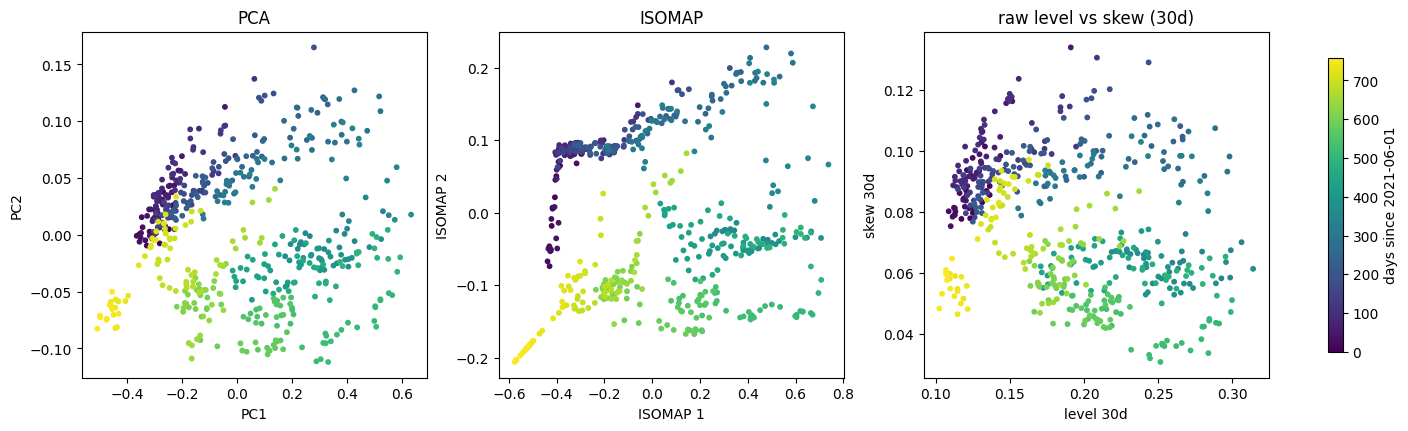

In [11]:
from sklearn.manifold import Isomap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Z = Isomap(n_neighbors=10, n_components=3).fit_transform(X)
P = pca.transform(X)[:, :3]

print('linear-decode R^2 (reconstruct all 63 grid IVs from k coordinates):')
for k in [1, 2, 3]:
    r2_iso = r2_score(X, LinearRegression().fit(Z[:, :k], X).predict(Z[:, :k]),
                      multioutput='variance_weighted')
    print(f'  k={k}:   ISOMAP {r2_iso:.3f}   PCA {evr[:k].sum():.3f}')

drivers = pd.DataFrame({'level (91d ATM)': feat[(91, 'level')],
                        'term slope (365d-30d)': feat[(365, 'level')] - feat[(30, 'level')],
                        'skew (30d)': feat[(30, 'skew')]}, index=dates)
cm = pd.DataFrame({f'ISO{k + 1}': [np.corrcoef(Z[:, k], drivers[c])[0, 1] for c in drivers]
                   for k in range(3)}, index=drivers.columns)
print('\ncorrelation of ISOMAP coordinates with the interpretable drivers:')
print(cm.round(2))

tnum = (dates - dates[0]).days
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax_, xv, yv, xl, yl, ti in [
        (axes[0], P[:, 0], P[:, 1], 'PC1', 'PC2', 'PCA'),
        (axes[1], Z[:, 0], Z[:, 1], 'ISOMAP 1', 'ISOMAP 2', 'ISOMAP'),
        (axes[2], feat[(30, 'level')], feat[(30, 'skew')], 'level 30d', 'skew 30d', 'raw level vs skew (30d)')]:
    sc = ax_.scatter(xv, yv, c=tnum, cmap='viridis', s=10)
    ax_.set_xlabel(xl); ax_.set_ylabel(yl); ax_.set_title(ti)
fig.colorbar(sc, ax=axes, label='days since 2021-06-01', shrink=0.85)
plt.show()

## Findings

**0. The data checks out.** 523 days × 63 grid points, zero NaNs, IVs in 9–43%; the put skew is positive on **100% of days**; the term structure is upward 74% of days (it inverts in stress, as it should). Sampled monthly, the grid ATM-30d sits a median 0.6 vol pts from the nearest raw quote — the gap is the expiry mismatch (grid = exactly 30d via total-variance interpolation, quote = nearest listed expiry), not an error.

**1. The skew is real, big, and decays with tenor.** Average skew (`IV(0.95) - IV(1.05)`) runs from **7.6 vol points at 30d to 3.7 at 365d**; curvature is concentrated at the short end.

**2. The crash-day microscope (2022-06-10 → 06-13, -4.7%).** Sticky delta predicted 30d ATM unchanged at 25.8%; sticky strike predicted 28.6%; **actual: 31.4%** — the smile floated left in moneyness *and* jumped up, overshooting even sticky strike. In moneyness coordinates the *shape* barely changed; the *height* exploded. That is the whole reconciliation in one picture.

**3. SPX is *not* sticky-delta — it sits between sticky-strike and the stoch-vol limit.** SSR declines monotonically from **1.31 at 30d to 0.96 at 365d**, with regression R² of 0.66–0.77 (forward returns explain most of daily ATM-vol changes — sticky delta predicts they would explain nothing). Short-dated smiles over-react beyond the slide (leverage effect); 1-year smiles are almost exactly sticky-strike. Range and tenor-ordering match the stochastic-vol literature.

**4. Natenberg is right about coordinates, not about dynamics.** The floating skew (his Fig 24-4) is the correct way to *store* the smile — shape is sticky in moneyness, which is exactly why our K/F grid and the one-big-level-factor PCA below work. But as a *prediction* for ATM vol, the float's height is strongly anti-correlated with spot, so the net effect lands at sticky-strike-plus, not sticky-delta.

**5. The linear factor model is confirmed — again.** PC1/PC2/PC3 = **93.3% / 4.1% / 1.6% (99.0% cumulative)**, loadings = level / term-tilt / skew-tilt (Cont & da Fonseca).

**6. ISOMAP finds nothing PCA doesn't.** Linear-decode R² is *below* PCA at every k (k=3: 0.978 vs 0.990), and **ISO1 correlates 1.00 with the level factor**, ISO2 0.83 with the skew — ISOMAP rediscovered the linear answer. The level–skew coupling and the 2022 regime loop are visible in the raw feature plane but live in a nearly flat 2-plane; the manifold isn't curved enough for geodesics to pay.

**Bottom line:** the surface panel supports rich *economics* (skew term structure, SSR ≈ 1.3 → 1.0, regime behavior) while its *geometry* stays linear — the interesting structure is in the dynamics, not in manifold curvature.